# ARIMA Modeling of S&P 500

**Objective:**

The objective of this notebook is to model and forecast S&P 500 log returns using ARIMA models in order to evaluate whether past values of returns contain predictive information about future returns.

This analysis is motivated by a key question in financial time series: whether equity returns exhibit predictable structure in their mean. While prior exploratory analysis suggests that returns are largely uncorrelated, formally fitting ARIMA models allows us to test this hypothesis within a statistical framework.

Understanding the extent (or absence) of predictability in returns is important for:
- Assessing market efficiency
- Establishing a baseline model for time-series forecasting
- Motivating the need for alternative models (eg GARCH) that focus on volatility rather than mean dynamics

This notebook therefore serves as a bridge between exploratory analysis and volatility modeling by demonstrating the limitations of mean-based models in financial data.

## Housekeeping

In [128]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from volatility_forecasting.data.loader import download_price_data
from volatility_forecasting.features.preprocessing import compute_log_returns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
# Set color palette to pastel and plot size
sns.set_theme(style="darkgrid")
plt.style.use("seaborn-v0_8-pastel")

plt.rcParams["figure.figsize"] = (15, 6)

In [136]:
# Download price data for S&P 500 and VIX and log transform prices, pulls in the loaded data if already downloaded

# SP500
sp500 = download_price_data("^GSPC")
sp500 = compute_log_returns(sp500)

## ARIMA Modelling

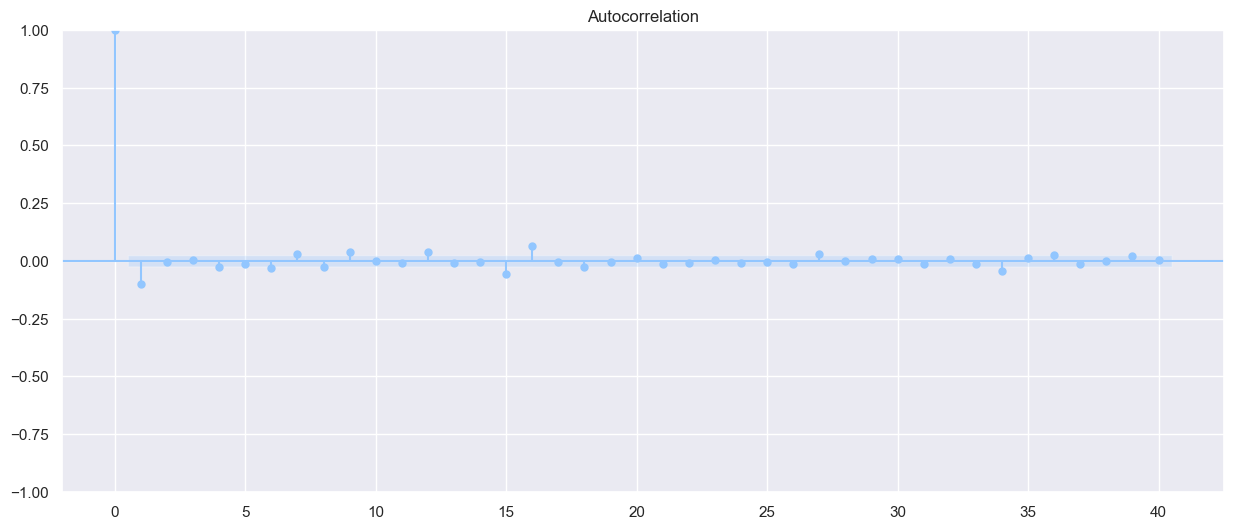

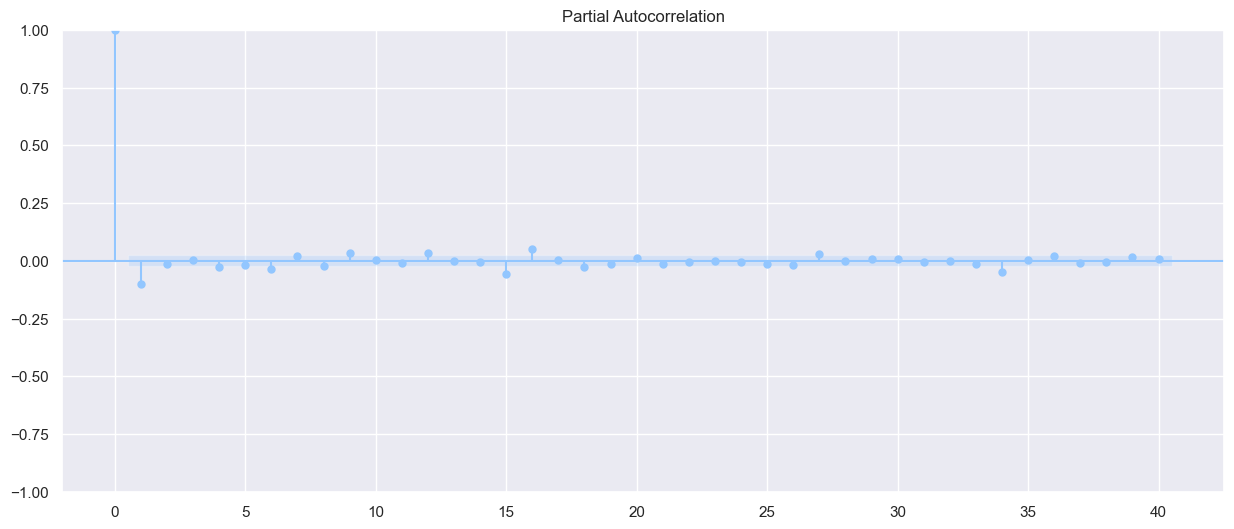

In [137]:
# Compute and plot ACF and PACF for log returns
log_return_acf = plot_acf(sp500["log_return"], lags=40)
log_return_pacf = plot_pacf(sp500["log_return"], lags=40)

No strong AR or MA structure => ARIMA is a weak model for returns

### Fitting ARIMA

Checking if any weak structures exists

In [138]:
# Model AR(1)
model = ARIMA(sp500["log_return"], order=(1, 0, 0))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\1412r\volatility-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\1412r\volatility-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\1412r\volatility-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 6592
Model:                 ARIMA(1, 0, 0)   Log Likelihood               19733.871
Date:                Sun, 22 Mar 2026   AIC                         -39461.741
Time:                        22:54:10   BIC                         -39441.360
Sample:                             0   HQIC                        -39454.697
                               - 6592                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.609      0.108   -4.89e-05       0.000
ar.L1         -0.0999      0.006    -16.524      0.000      -0.112      -0.088
sigma2         0.0001   1.07e-06    137.463      0.0

In [139]:
# Model MA(1)
model = ARIMA(sp500["log_return"], order=(0, 0, 1))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\1412r\volatility-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\1412r\volatility-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\1412r\volatility-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 6592
Model:                 ARIMA(0, 0, 1)   Log Likelihood               19734.469
Date:                Sun, 22 Mar 2026   AIC                         -39462.938
Time:                        22:54:26   BIC                         -39442.557
Sample:                             0   HQIC                        -39455.894
                               - 6592                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.609      0.108   -4.89e-05       0.000
ma.L1         -0.1013      0.006    -16.042      0.000      -0.114      -0.089
sigma2         0.0001   1.08e-06    136.065      0.0

In [140]:
model = ARIMA(sp500["log_return"], order=(1, 0, 1))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\1412r\volatility-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\1412r\volatility-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\1412r\volatility-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 6592
Model:                 ARIMA(1, 0, 1)   Log Likelihood               19734.527
Date:                Sun, 22 Mar 2026   AIC                         -39461.055
Time:                        22:54:32   BIC                         -39433.880
Sample:                             0   HQIC                        -39451.663
                               - 6592                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.579      0.114   -5.42e-05       0.001
ar.L1          0.0331      0.050      0.668      0.504      -0.064       0.130
ma.L1         -0.1345      0.050     -2.688      0.0

Although alternative ARIMA specifications such as (1, 0, 1) were tested, the coefficients were largely insignificant and did not materially improve model performance. This suggests that S&P 500 returns do not exhibit meaningful autocorrelation and behave close to white noise.

However, volatility clustering observed in squared returns indicates that while the mean is not preidcatble, the variance is time-varying - motivating the use of GARCH models.

### Residual Diagnostics

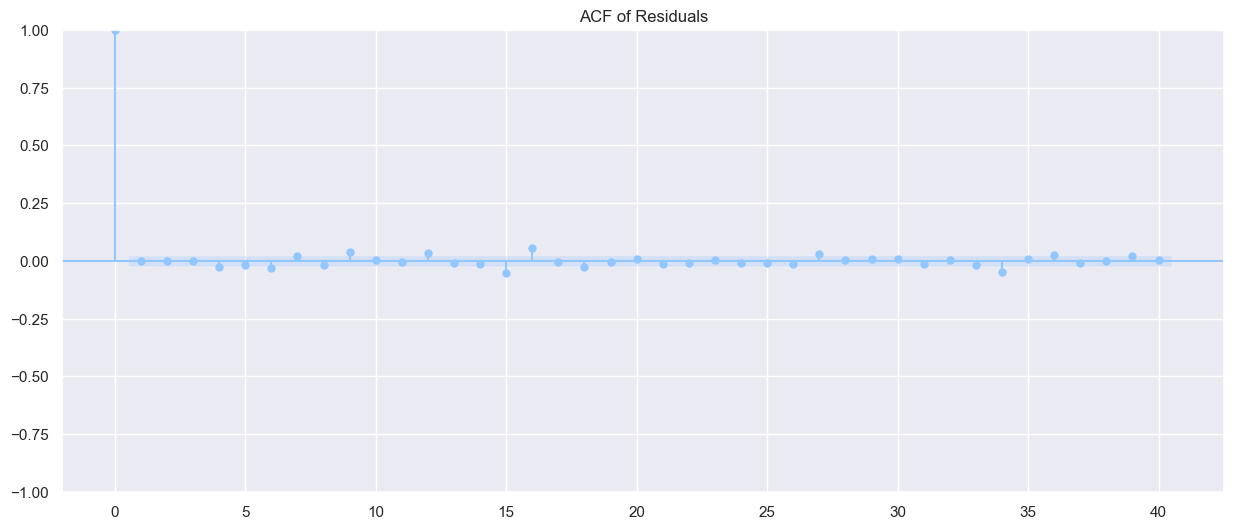

In [141]:
# Check residuals for autocorrelation
residuals = model_fit.resid
resid_acf = plot_acf(residuals, lags=40, title="ACF of Residuals")

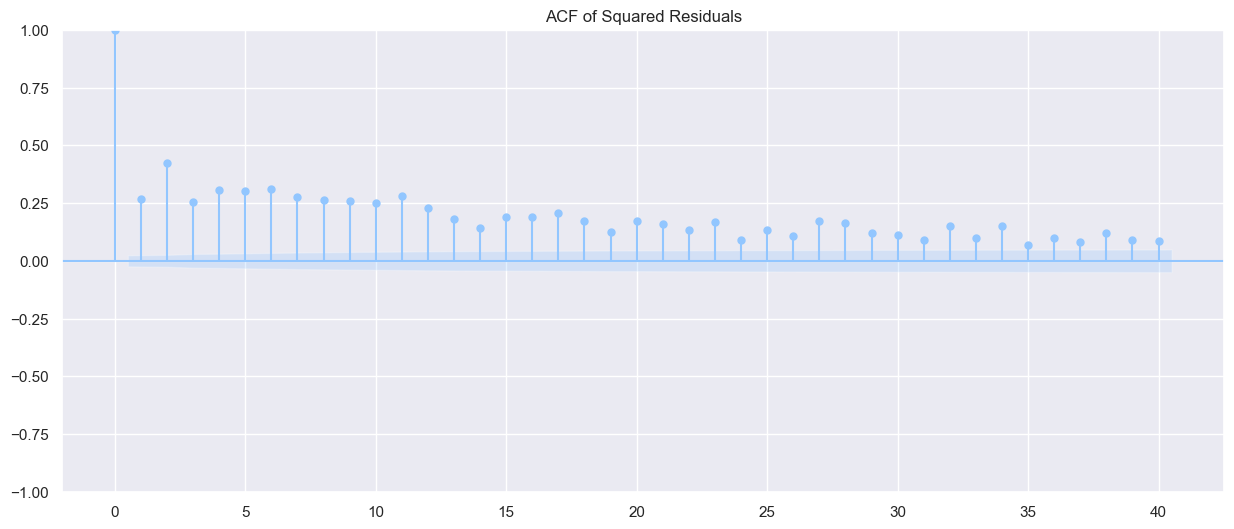

In [142]:
# Check autocorrelation of residuals squares to detect ARCH effects
resid_squared_acf = plot_acf(residuals**2, lags=40, title="ACF of Squared Residuals")

The ACF plot of the residuals show no significant autocorrelation, indicating that the ARIMA model has successfully captured any linear dependence in the mean of the series.

But the squared residuals might be explained by the past values, hence prompting GARCH modelling

## Forecasting

In [145]:
# Reindex to ensure continuous date index for forecasting
sp500 = sp500.asfreq("B")  # Set frequency to business day
model = ARIMA(sp500["log_return"], order=(1, 0, 1))
model_fit = model.fit()

In [146]:
forecast = model_fit.get_forecast(steps=1500)

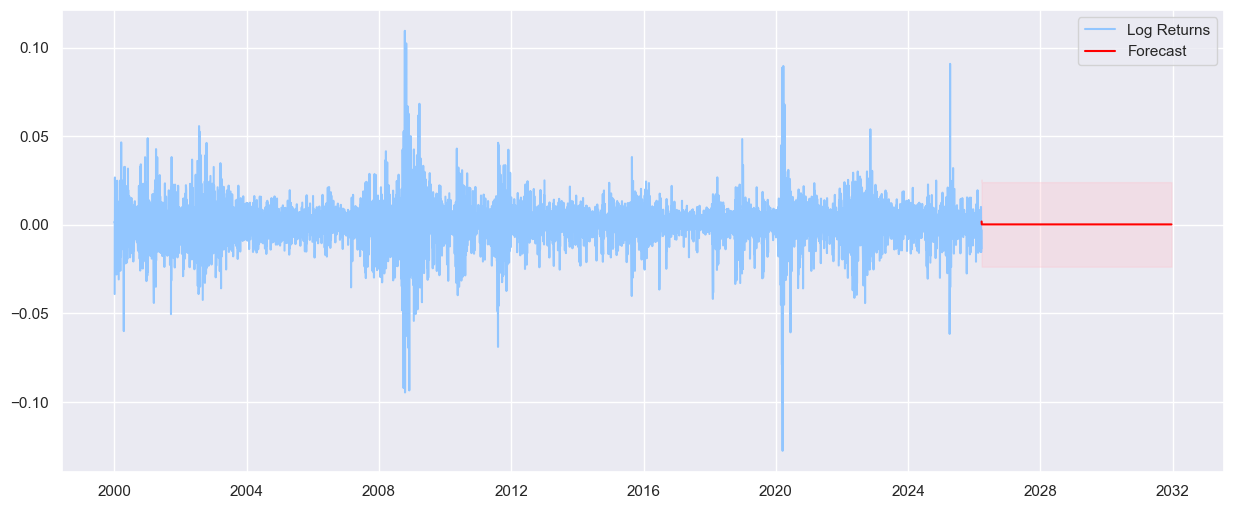

In [147]:
plt.plot(sp500.index, sp500["log_return"], label="Log Returns")
plt.plot(forecast.predicted_mean.index, forecast.predicted_mean, label="Forecast", color="red")
plt.fill_between(forecast.conf_int().index, forecast.conf_int()["lower log_return"], forecast.conf_int()["upper log_return"], color="pink", alpha=0.3)
plt.legend()

Forecasting is used here not as a strong prediction of the future, but to evaluate whether past return dynamics contain meaningful information about the future values.

In financial markets, returns are often assumed to follow a near-random process. By generating foreast using ARIMA, we can empirically assess this assumtion and determine whether mean-based models provide any predictive advantage.

This also establishes a baseline for comparison with volatility models, which aim to capture time-varying risk rather than directional predictability.